In [1]:
# VEGA (Vector Evaluated Genetic Algorithm) on the Capacitated Facility Location Problem (CFLP)
#
# The problem in plain words:
#   A company has m candidate warehouses ("facilities") and n customers.
#   We decide which facility serves each customer.
#   A facility is OPEN when at least one customer uses it, and opening it costs money (its fixed cost).
#   Serving a customer from a facility also costs money (the allocation cost).
#   A facility can not serve more demand than its capacity.
#
# We want to make TWO costs small at the same time:
#   f1 = total opening cost    = the fixed cost of every open facility, added up
#   f2 = total allocation cost = the cost of serving each customer from its facility, added up
# The two fight each other: fewer facilities -> lower f1, but customers are served from further away -> higher f2.
# So there is no single best answer, only trade-offs. VEGA tries to find a set of good trade-offs.
#
# Written like the Lab 3 script (vega_lab.py): plain Python lists and the random module.

import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt

# The notebook may be started from the repo root or from experiment/. Find the repo root either way,
# so we can reach the data/ folder and the shared settings in app/config.py.
ROOT = Path.cwd().parent if Path.cwd().name == "experiment" else Path.cwd()
sys.path.insert(0, str(ROOT))

# The settings (population size, number of evaluations, crossover and mutation rates) are shared with
# the other MOEA in app/config.py. Both algorithms must use the same values, or the comparison is unfair.
from app.config import BASE_SEED, CONFIGS

for config in CONFIGS:
    print(config.name, "| population:", config.pop_size, "| evaluations:", config.max_evaluations,
          "| crossover rate:", config.crossover_prob, "| customers moved per child:", config.mutation_flips)

SEED = BASE_SEED          # a fixed seed, so every run can be repeated exactly
NUMBER_OF_OBJECTIVES = 2  # f1 and f2

C1 | population: 50 | evaluations: 10000 | crossover rate: 0.9 | mutation rate: 0.05
C2 | population: 100 | evaluations: 20000 | crossover rate: 0.9 | mutation rate: 0.02
C3 | population: 200 | evaluations: 40000 | crossover rate: 0.8 | mutation rate: 0.01


In [2]:
# Step 1: read the OR-Library data file.
#
# The file is just numbers separated by spaces and new lines:
#   m n                        -> number of facilities, number of customers
#   capacity  fixed_cost       -> one line for every facility (m lines)
#   demand                     -> then for every customer: its demand,
#   cost_1 cost_2 ... cost_m   ->   followed by the cost of serving ALL its demand from each facility
#
# We use the numbers exactly as they are in the file (the assignment forbids changing them).

def load_instance(name):
    numbers = (ROOT / "data" / f"{name}.txt").read_text().split()
    m = int(numbers[0])
    n = int(numbers[1])
    position = 2  # where we are in the list of numbers

    capacity = []    # capacity[i]   = how much demand facility i can hold
    fixed_cost = []  # fixed_cost[i] = what it costs to open facility i
    for i in range(m):
        capacity.append(float(numbers[position]))
        fixed_cost.append(float(numbers[position + 1]))
        position += 2

    demand = []                                 # demand[j] = how much customer j needs
    alloc_cost = [[0.0] * n for i in range(m)]  # alloc_cost[i][j] = cost of serving customer j from facility i
    for j in range(n):
        demand.append(float(numbers[position]))
        position += 1
        for i in range(m):
            alloc_cost[i][j] = float(numbers[position])
            position += 1

    return {"name": name, "m": m, "n": n, "capacity": capacity,
            "fixed_cost": fixed_cost, "demand": demand, "alloc_cost": alloc_cost}


instance = load_instance("cap121")

print("facilities (m):", instance["m"], "  customers (n):", instance["n"])
print("facility 0 -> capacity", instance["capacity"][0], " fixed cost", instance["fixed_cost"][0])
print("customer 0 -> demand", instance["demand"][0],
      " cost from facilities 0-4:", [instance["alloc_cost"][i][0] for i in range(5)])
print("total demand of all customers:", sum(instance["demand"]))
print("cost of opening every facility:", sum(instance["fixed_cost"]))

facilities (m): 50   customers (n): 50
facility 0 -> capacity 15000.0  fixed cost 7500.0
customer 0 -> demand 146.0  cost from facilities 0-4: [2609.75, 3292.3, 6739.725, 8933.375, 6803.6]
total demand of all customers: 58268.0
cost of opening every facility: 367500.0


In [3]:
# Step 2: how one solution (an "individual") is stored.
#
# An individual is a list with one number per customer: the facility that serves that customer.
#   individual[j] = i   means   "customer j is served by facility i"
#
# Example with 5 customers:  [3, 7, 3, 12, 7]
#   customers 0 and 2 -> facility 3, customers 1 and 4 -> facility 7, customer 3 -> facility 12,
#   so facilities 3, 7 and 12 are open (they have customers) and all the others are closed.
#
# Nice property: every customer automatically has exactly one facility, and a facility is open exactly
# when someone uses it. The only rule this can break is capacity (too much demand on one facility).

rng = random.Random(SEED)

def random_individual(instance, rng):
    # every customer picks a random facility
    return [rng.randrange(instance["m"]) for j in range(instance["n"])]


example = random_individual(instance, rng)
print("first 10 genes:", example[:10])
print("open facilities:", sorted(set(example)))
print("that is", len(set(example)), "of the", instance["m"], "facilities")

first 10 genes: [40, 7, 1, 47, 17, 15, 14, 8, 47, 6]
open facilities: [0, 1, 2, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 17, 21, 24, 26, 27, 28, 32, 34, 35, 37, 38, 40, 41, 43, 44, 45, 47, 48]
that is 31 of the 50 facilities


In [4]:
# Step 3: capacity check and repair.
#
# load of facility i = the demand of all customers assigned to i, added up.
# The capacity rule: load of i <= capacity of i, for every facility.
# A random individual can break this rule, so we "repair" it:
#   while some facility is overloaded:
#       take its customers in random order and move them one by one to a random facility
#       that still has room, until the overloaded facility fits again.
# After repair the solution is always feasible, and only then do we calculate f1 and f2.

def facility_loads(individual, instance):
    loads = [0.0] * instance["m"]
    for customer in range(instance["n"]):
        facility = individual[customer]
        loads[facility] += instance["demand"][customer]
    return loads


def overloaded_facilities(individual, instance):
    loads = facility_loads(individual, instance)
    return [i for i in range(instance["m"]) if loads[i] > instance["capacity"][i]]


def repair(individual, instance, rng):
    repaired = individual.copy()  # work on a copy, never change the original
    capacity = instance["capacity"]
    demand = instance["demand"]
    loads = facility_loads(repaired, instance)

    while True:
        overloaded = [i for i in range(instance["m"]) if loads[i] > capacity[i]]
        if len(overloaded) == 0:
            return repaired  # nothing is overloaded any more: done

        facility = overloaded[0]
        customers = [j for j in range(instance["n"]) if repaired[j] == facility]
        rng.shuffle(customers)

        for customer in customers:
            if loads[facility] <= capacity[facility]:
                break  # this facility fits now, stop moving its customers

            # take the customer away from the overloaded facility ...
            loads[facility] -= demand[customer]
            # ... and list every facility that has room for it
            with_room = [i for i in range(instance["m"]) if loads[i] + demand[customer] <= capacity[i]]
            if len(with_room) > 0:
                new_facility = rng.choice(with_room)
            else:
                # nobody has room: use the facility with the most free space
                new_facility = max(range(instance["m"]), key=lambda i: capacity[i] - loads[i])
            repaired[customer] = new_facility
            loads[new_facility] += demand[customer]


# Try it on a deliberately bad individual: every customer uses facility 0.
bad = [0] * instance["n"]
print("before repair -> overloaded facilities:", overloaded_facilities(bad, instance))
fixed = repair(bad, instance, rng)
print("after repair  -> overloaded facilities:", overloaded_facilities(fixed, instance),
      "| open facilities:", len(set(fixed)))

before repair -> overloaded facilities: [0]
after repair  -> overloaded facilities: [] | open facilities: 24


In [5]:
# Step 4: the two objectives.
#
# f1 = fixed_cost[i] of every OPEN facility i, added up (each open facility counted once)
# f2 = alloc_cost[i][j] for every customer j, added up, where i is the facility serving j
#      (alloc_cost already covers all of the customer's demand, so we do NOT multiply by the demand again)

def evaluate(individual, instance):
    open_facilities = set(individual)  # a set keeps each facility only once
    f1 = 0.0
    for i in open_facilities:
        f1 += instance["fixed_cost"][i]
    f2 = 0.0
    for customer in range(instance["n"]):
        facility = individual[customer]
        f2 += instance["alloc_cost"][facility][customer]
    return f1, f2


f1, f2 = evaluate(fixed, instance)
print(f"repaired 'bad' individual: {len(set(fixed))} open facilities, f1 = {f1:,.0f}, f2 = {f2:,.0f}")

random_one = repair(random_individual(instance, rng), instance, rng)
f1, f2 = evaluate(random_one, instance)
print(f"random individual:         {len(set(random_one))} open facilities, f1 = {f1:,.0f}, f2 = {f2:,.0f}")

repaired 'bad' individual: 24 open facilities, f1 = 180,000, f2 = 2,826,330
random individual:         31 open facilities, f1 = 232,500, f2 = 2,011,815


In [6]:
# Step 5: comparing two solutions when there are two objectives.
#
# Solution A "dominates" solution B when:
#   1. A is not worse than B in any objective, and
#   2. A is strictly better than B in at least one objective.
# If neither dominates the other, they are simply different trade-offs.

def dominates(a, b):
    not_worse_anywhere = all(x <= y for x, y in zip(a, b))
    better_somewhere = any(x < y for x, y in zip(a, b))
    return not_worse_anywhere and better_somewhere


# The example from the Lab 3 slides (page 4), written as (f1, f2):
A, B, C, D = (2, 4), (3, 3), (1, 5), (3, 5)
print("A dominates D?        ", dominates(A, D))                        # True: 2 < 3 and 4 < 5
print("A and B, one dominates?", dominates(A, B) or dominates(B, A))    # False: A has lower f1, B lower f2
print("A and C, one dominates?", dominates(A, C) or dominates(C, A))    # False: C has lower f1, A lower f2

A dominates D?         True
A and B, one dominates? False
A and C, one dominates? False


In [7]:
# Step 6: roulette-wheel selection (picking parents, where better solutions are picked more often).
#
# Imagine a wheel where every solution owns a slice: a bigger slice means a bigger chance to be picked.
# We minimise, so a SMALLER cost must give a BIGGER slice. We use the lecture's scaling (Lecture 3, slide 39):
#     slice = worst cost in the group - my cost
# The best solution gets the biggest slice and the worst solution gets no slice at all.
#
# To "spin" the wheel: draw a random number between 0 and the total size of all slices,
# then walk along the slices until the running total passes that number.

def roulette_wheel_selection(costs, how_many, rng):
    worst = max(costs)
    slices = [worst - cost for cost in costs]
    total = sum(slices)

    if total == 0:
        # everybody has the same cost: every slice is empty, so just pick at random
        return [rng.randrange(len(costs)) for k in range(how_many)]

    chosen = []
    for k in range(how_many):
        spin = rng.random() * total
        running_total = 0.0
        for position in range(len(slices)):
            running_total += slices[position]
            if spin < running_total:
                chosen.append(position)
                break
        else:
            # very rare rounding case: the spin landed exactly on the end of the wheel
            chosen.append(max(p for p in range(len(slices)) if slices[p] > 0))
    return chosen


# The example from the Lab 3 slides (page 10): three solutions with costs 0, 1 and 9.
costs = [0, 1, 9]
lab_weights = [1 / (1 + c) for c in costs]        # the lab's formula
lecture_slices = [max(costs) - c for c in costs]  # the lecture's formula (the one used here)
print("small costs", costs)
print("  chance with lab 1/(1+f):    ", [f"{w / sum(lab_weights):.1%}" for w in lab_weights])
print("  chance with lecture worst-f:", [f"{s / sum(lecture_slices):.1%}" for s in lecture_slices])

# Why the lecture's formula: CFLP costs are huge. With costs around a million,
# 1/(1+f) gives everybody almost the same chance, so selection becomes nearly random.
big_costs = [1_000_000, 1_100_000, 1_200_000]
lab_weights = [1 / (1 + c) for c in big_costs]
lecture_slices = [max(big_costs) - c for c in big_costs]
print("CFLP-sized costs", big_costs)
print("  chance with lab 1/(1+f):    ", [f"{w / sum(lab_weights):.1%}" for w in lab_weights])
print("  chance with lecture worst-f:", [f"{s / sum(lecture_slices):.1%}" for s in lecture_slices])

# Spin the wheel 10,000 times on the small example and count the picks: they should follow the lecture chances.
counts = [0, 0, 0]
for position in roulette_wheel_selection(costs, 10_000, rng):
    counts[position] += 1
print("picked out of 10,000 spins:", counts)

small costs [0, 1, 9]
  chance with lab 1/(1+f):     ['62.5%', '31.2%', '6.2%']
  chance with lecture worst-f: ['52.9%', '47.1%', '0.0%']
CFLP-sized costs [1000000, 1100000, 1200000]
  chance with lab 1/(1+f):     ['36.5%', '33.1%', '30.4%']
  chance with lecture worst-f: ['66.7%', '33.3%', '0.0%']
picked out of 10,000 spins: [5303, 4697, 0]


In [8]:
# Step 7: VEGA's selection (Lecture 3, slides 33-35). This is the ONLY part that makes it VEGA.
#
#   1. shuffle the population, so the split is random
#   2. split it into 2 equal parts, one part per objective: q = N / 2
#   3. part 1 picks q parents looking ONLY at f1, part 2 picks q parents looking ONLY at f2
#   4. put both groups of parents together and shuffle again,
#      so a parent that is cheap to open can mate with a parent that is cheap to allocate

def vega_selection(population, objectives, rng):
    indices = list(range(len(population)))
    rng.shuffle(indices)
    part_size = len(population) // NUMBER_OF_OBJECTIVES

    mating_pool = []
    for objective in range(NUMBER_OF_OBJECTIVES):         # objective 0 = f1, objective 1 = f2
        start = objective * part_size
        part = indices[start:start + part_size]            # the members of this part
        costs = [objectives[i][objective] for i in part]   # their cost on THIS objective only
        picked = roulette_wheel_selection(costs, part_size, rng)
        for position in picked:
            mating_pool.append(population[part[position]].copy())

    rng.shuffle(mating_pool)
    return mating_pool


# Try it on 50 random (repaired) individuals: on average the parents should be cheaper than the population.
population = [repair(random_individual(instance, rng), instance, rng) for k in range(50)]
objectives = [evaluate(individual, instance) for individual in population]
parents = vega_selection(population, objectives, rng)
parent_objectives = [evaluate(parent, instance) for parent in parents]

# Half of the pool was chosen on f1 only and the other half on f2 only, so each mean drops only a little here.
# The drop is small, but it happens in every generation (199 times in a run), and that is what moves the population.
print("mating pool size:", len(parents))
for objective, name in [(0, "f1"), (1, "f2")]:
    population_mean = sum(o[objective] for o in objectives) / len(objectives)
    parents_mean = sum(o[objective] for o in parent_objectives) / len(parent_objectives)
    print(f"{name}: population mean {population_mean:>12,.0f}   ->   mating pool mean {parents_mean:>12,.0f}")

mating pool size: 50
f1: population mean      230,850   ->   mating pool mean      226,350
f2: population mean    2,585,143   ->   mating pool mean    2,577,603


In [9]:
# Step 8: making children.
#
# One-point crossover: cut both parents at the same random place and swap the tails.
#   parent 1 = [3, 7, 3 | 12, 7]        child 1 = [3, 7, 3 | 5, 5]
#   parent 2 = [9, 5, 1 |  5, 5]   ->   child 2 = [9, 5, 1 | 12, 7]
#
# Mutation: for every customer, with a small probability, move it to ANOTHER facility that is already open.
#   If it was the last customer of its old facility, that facility closes and f1 goes down.
#   (This plays the role of the lab's small random step: it changes one gene's value a little.)

def one_point_crossover(parent1, parent2, rng):
    point = rng.randint(1, len(parent1) - 1)  # never cut at the very start or the very end
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2


def mutation(individual, mutation_rate, rng):
    mutated = individual.copy()
    for customer in range(len(mutated)):
        if rng.random() < mutation_rate:
            open_facilities = sorted(set(mutated))
            other_open = [f for f in open_facilities if f != mutated[customer]]
            if len(other_open) > 0:
                mutated[customer] = rng.choice(other_open)
    return mutated


parent1, parent2 = [3, 7, 3, 12, 7], [9, 5, 1, 5, 5]
print("crossover of", parent1, "and", parent2, "->", one_point_crossover(parent1, parent2, rng))
print("mutation of", parent1, "->", mutation(parent1, 0.5, rng), " (rate 0.5 here only so changes are visible)")

crossover of [3, 7, 3, 12, 7] and [9, 5, 1, 5, 5] -> ([3, 7, 3, 5, 5], [9, 5, 1, 12, 7])
mutation of [3, 7, 3, 12, 7] -> [7, 12, 3, 3, 7]  (rate 0.5 here only so changes are visible)


In [10]:
# Step 9: one full VEGA run.
#
# reproduce(): take the parents two at a time -> crossover (with some probability) -> mutation -> repair.
# run_vega(): the loop from the lecture's flowchart:
#   population -> evaluate -> VEGA selection -> crossover/mutation -> new population -> ... until the budget is used.
# The children completely replace the parents every generation (like the lab and the lecture's schematic).
# Every evaluated individual counts as 1 evaluation, and the run stops after max_evaluations evaluations.

def reproduce(mating_pool, instance, crossover_rate, mutation_rate, rng):
    children = []
    for k in range(0, len(mating_pool), 2):
        parent1, parent2 = mating_pool[k], mating_pool[k + 1]
        if rng.random() < crossover_rate:
            child1, child2 = one_point_crossover(parent1, parent2, rng)
        else:
            child1, child2 = parent1.copy(), parent2.copy()  # no crossover: the children are copies

        for child in (child1, child2):
            child = mutation(child, mutation_rate, rng)
            children.append(repair(child, instance, rng))   # crossover and mutation can break capacity
    return children


def run_vega(instance, config, seed):
    rng = random.Random(seed)

    population = [repair(random_individual(instance, rng), instance, rng) for k in range(config.pop_size)]
    objectives = [evaluate(individual, instance) for individual in population]
    evaluations = len(population)
    history = [objectives]  # the objectives of every generation, used for the plots later

    while evaluations < config.max_evaluations:
        parents = vega_selection(population, objectives, rng)
        mutation_rate = config.mutation_flips / instance["n"]  # per customer, so as many genes change as in app/
        population = reproduce(parents, instance, config.crossover_prob, mutation_rate, rng)
        objectives = [evaluate(individual, instance) for individual in population]
        evaluations += len(population)
        history.append(objectives)

    return objectives, history

In [11]:
# Step 10: the result of a run is the set of solutions that no other solution dominates (the "non-dominated set").
# We also remove duplicates (two identical solutions are one trade-off, not two)
# and sort by f1, so later we can draw a line through them from left to right.

def nondominated(objectives):
    unique = sorted(set(objectives))
    front = []
    for candidate in unique:
        beaten = False
        for other in unique:
            if dominates(other, candidate):
                beaten = True
                break
        if not beaten:
            front.append(candidate)
    return front


# Tiny check with made-up points: (3, 3) is beaten by (2, 2), and (2, 2) appears twice.
print(nondominated([(1, 5), (2, 2), (2, 2), (3, 3), (4, 1)]))  # -> [(1, 5), (2, 2), (4, 1)]

[(1, 5), (2, 2), (4, 1)]


In [12]:
# Step 11: run VEGA once with configuration C1 and look at the result.

config = CONFIGS[0]
start = time.perf_counter()
final_objectives, history = run_vega(instance, config, SEED)
seconds = time.perf_counter() - start

front = nondominated(final_objectives)
print(f"{config.name}: {len(history) - 1} generations, {len(history) * config.pop_size} evaluations, {seconds:.2f} seconds")
print(f"{len(front)} non-dominated solutions:")
for f1, f2 in front:
    print(f"   f1 = {f1:>9,.0f}   f2 = {f2:>12,.0f}")

C1: 199 generations, 10000 evaluations, 0.10 seconds
2 non-dominated solutions:
   f1 =    52,500   f2 =    1,469,533
   f1 =    67,500   f2 =    1,380,867


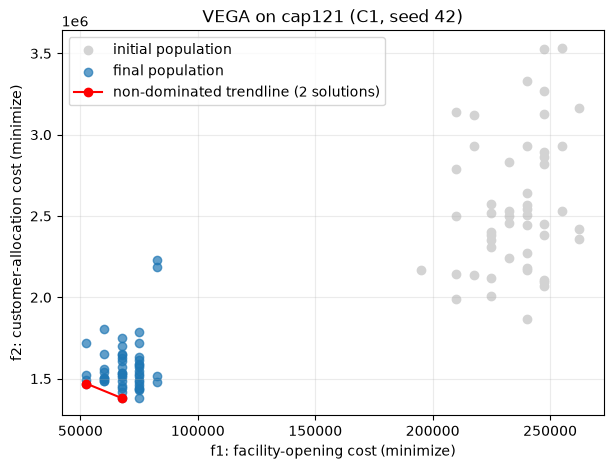

In [13]:
# Step 12: plot the run.
#   grey = the random population we started with
#   blue = the population after the last generation
#   red  = the non-dominated solutions, joined by a line (the trendline) in order of f1
#
# In the lab the true Pareto front is a smooth curve, because x can be any real number.
# Here f1 can only change in whole facilities, and nobody knows the true front of cap121,
# so the best we can draw is a line through the non-dominated solutions we found.

def plot_run(history, title):
    first, last = history[0], history[-1]
    front = nondominated(last)
    plt.figure(figsize=(7, 5))
    plt.scatter([o[0] for o in first], [o[1] for o in first], color="lightgray", label="initial population")
    plt.scatter([o[0] for o in last], [o[1] for o in last], alpha=0.7, label="final population")
    plt.plot([o[0] for o in front], [o[1] for o in front], "o-", color="red",
             label=f"non-dominated trendline ({len(front)} solutions)")
    plt.title(title)
    plt.xlabel("f1: facility-opening cost (minimize)")
    plt.ylabel("f2: customer-allocation cost (minimize)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


plot_run(history, f"VEGA on {instance['name']} ({config.name}, seed {SEED})")

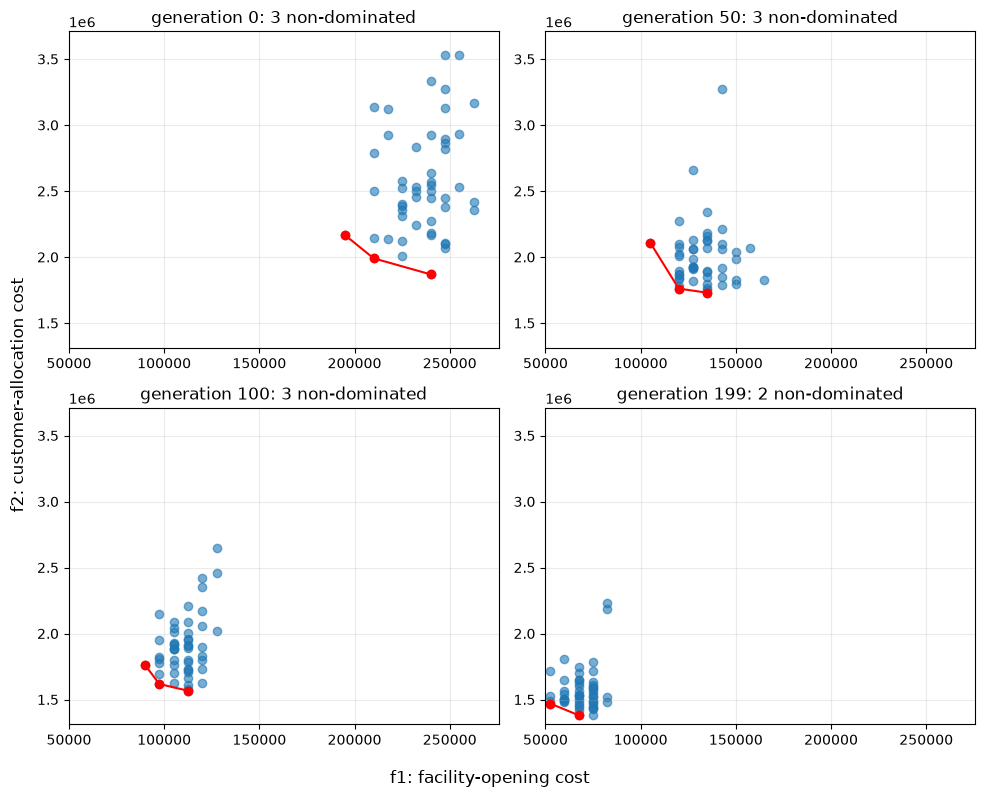

In [14]:
# Step 13: watch the population move. Four snapshots of the same run: generation 0, 50, 100 and the last one.
# All four use the same axes, so you can compare where the population is.

snapshots = [0, 50, 100, len(history) - 1]
all_points = [o for g in snapshots for o in history[g]]
x_range = (min(o[0] for o in all_points) * 0.95, max(o[0] for o in all_points) * 1.05)
y_range = (min(o[1] for o in all_points) * 0.95, max(o[1] for o in all_points) * 1.05)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, generation in zip(axes.flat, snapshots):
    generation_objectives = history[generation]
    front = nondominated(generation_objectives)
    ax.scatter([o[0] for o in generation_objectives], [o[1] for o in generation_objectives], alpha=0.6)
    ax.plot([o[0] for o in front], [o[1] for o in front], "o-", color="red")
    ax.set_title(f"generation {generation}: {len(front)} non-dominated")
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)
    ax.grid(alpha=0.25)
fig.supxlabel("f1: facility-opening cost")
fig.supylabel("f2: customer-allocation cost")
plt.tight_layout()
plt.show()

config  population evaluations front size   best f1      best f2  seconds


C1              50       10000          2    52,500    1,380,867     0.10
C2             100       20000          2    52,500    1,262,842     0.16


C3             200       40000          3    52,500    1,209,356     0.31


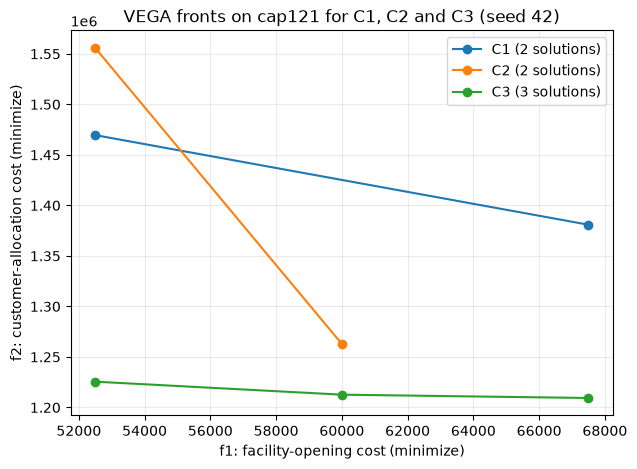

In [15]:
# Step 14: compare the three configurations (same instance, same seed).
# For each one: how many trade-offs were found, the cheapest f1 and f2 among them, and the running time.

results = {}
print(f"{'config':<7}{'population':>11}{'evaluations':>12}{'front size':>11}{'best f1':>10}{'best f2':>13}{'seconds':>9}")
for config in CONFIGS:
    start = time.perf_counter()
    final_objectives, config_history = run_vega(instance, config, SEED)
    seconds = time.perf_counter() - start
    front = nondominated(final_objectives)
    results[config.name] = front
    print(f"{config.name:<7}{config.pop_size:>11}{config.max_evaluations:>12}{len(front):>11}"
          f"{min(f[0] for f in front):>10,.0f}{min(f[1] for f in front):>13,.0f}{seconds:>9.2f}")

# all three fronts on one plot, each with its own trendline
plt.figure(figsize=(7, 5))
for name, front in results.items():
    plt.plot([f[0] for f in front], [f[1] for f in front], "o-", label=f"{name} ({len(front)} solutions)")
plt.title(f"VEGA fronts on {instance['name']} for C1, C2 and C3 (seed {SEED})")
plt.xlabel("f1: facility-opening cost (minimize)")
plt.ylabel("f2: customer-allocation cost (minimize)")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [16]:
# Step 15: same seed -> same random numbers -> exactly the same result.
# The assignment asks for runs that can be repeated, so this must print True.

first_run, _ = run_vega(instance, CONFIGS[0], SEED)
second_run, _ = run_vega(instance, CONFIGS[0], SEED)
print("same result both times:", first_run == second_run)

same result both times: True


In [17]:
# Step 16: a reference front to compare VEGA against (the CFLP version of the lab's dashed curve).
#
# The lab can draw the TRUE Pareto front from a formula. For CFLP nobody knows the true front,
# so we build a "reference front" with a different, more direct search and use it as a yardstick.
# It is NOT an evolutionary algorithm and it is not guaranteed to be optimal. It is just a strong comparison line.
#
# The idea: in cap121 every facility costs 7,500 to open (except one that is free), so f1 only depends on
# HOW MANY facilities are open. For every count we look for the set of facilities with the lowest f2:
#   1. drop: start with every facility open, then keep closing the facility whose closing raises f2 the least,
#            until the customers no longer fit. Every set we try is remembered if it is the best for its f1.
#   2. swap: for every f1, try closing one open facility and opening one closed facility instead,
#            and keep the swap whenever f2 goes down, until no swap helps any more.
# Given a set of open facilities, the customers are served greedily: the biggest customers first (they are
# the hardest to fit), each by the cheapest open facility that still has room.

def cheapest_facilities_per_customer(instance):
    # for every customer: all facilities, from cheapest to most expensive (worked out once, reused a lot)
    return [sorted(range(instance["m"]), key=lambda i: instance["alloc_cost"][i][j]) for j in range(instance["n"])]


def serve_customers(open_set, instance, cheapest_first):
    # returns an individual (the facility of every customer), or None if the customers do not fit
    loads = [0.0] * instance["m"]
    individual = [None] * instance["n"]
    biggest_first = sorted(range(instance["n"]), key=lambda j: instance["demand"][j], reverse=True)
    for customer in biggest_first:
        for facility in cheapest_first[customer]:
            if facility in open_set and loads[facility] + instance["demand"][customer] <= instance["capacity"][facility]:
                individual[customer] = facility
                loads[facility] += instance["demand"][customer]
                break
        else:
            return None  # no open facility had room for this customer
    return individual


def try_facilities(open_set, instance, cheapest_first, best):
    # serve the customers from these facilities and remember the result if it is the best f2 for its f1
    individual = serve_customers(open_set, instance, cheapest_first)
    if individual is None:
        return None
    f1, f2 = evaluate(individual, instance)
    if f1 not in best or f2 < best[f1][0]:
        best[f1] = (f2, set(individual))  # set(individual) = the facilities that are really used
    return f2


def reference_front(instance):
    cheapest_first = cheapest_facilities_per_customer(instance)
    best = {}  # best[f1] = (the lowest f2 found for this opening cost, the facilities used)

    # 1. drop
    open_set = set(range(instance["m"]))
    try_facilities(open_set, instance, cheapest_first, best)
    while True:
        best_to_close, lowest_f2 = None, None
        for facility in open_set:
            if instance["fixed_cost"][facility] == 0:
                continue  # closing a free facility can never lower f1, so we never do it
            f2 = try_facilities(open_set - {facility}, instance, cheapest_first, best)
            if f2 is not None and (lowest_f2 is None or f2 < lowest_f2):
                best_to_close, lowest_f2 = facility, f2
        if best_to_close is None:
            break  # closing any more facilities would leave customers without room
        open_set.remove(best_to_close)

    # 2. swap
    for f1 in sorted(best):
        improved = True
        while improved:
            improved = False
            f2_before, current = best[f1]
            for close in current:
                if instance["fixed_cost"][close] == 0:
                    continue
                for new in range(instance["m"]):
                    if new in current:
                        continue
                    try_facilities((current - {close}) | {new}, instance, cheapest_first, best)
                    if best[f1][0] < f2_before:  # this swap found a cheaper set for this f1: start again from it
                        improved = True
                        break
                if improved:
                    break

    return nondominated([(f1, best[f1][0]) for f1 in best])


start = time.perf_counter()
reference = reference_front(instance)
print(f"reference front: {len(reference)} points in {time.perf_counter() - start:.1f} seconds")
print(f"  fewest facilities: f1 = {reference[0][0]:>9,.0f}   f2 = {reference[0][1]:>12,.0f}")
print(f"  every facility:    f1 = {reference[-1][0]:>9,.0f}   f2 = {reference[-1][1]:>12,.0f}")

# Sanity check for the right-hand end: with every facility open, the best possible f2 is every customer at its
# own cheapest facility (capacity does not get in the way here), and the reference should reach exactly that.
lowest_possible_f2 = sum(min(instance["alloc_cost"][i][j] for i in range(instance["m"])) for j in range(instance["n"]))
print(f"  lowest possible f2 (every customer at its cheapest facility): {lowest_possible_f2:,.0f}")

reference front: 47 points in 0.2 seconds
  fewest facilities: f1 =    22,500   f2 =    1,035,027
  every facility:    f1 =   367,500   f2 =      624,071
  lowest possible f2 (every customer at its cheapest facility): 624,071


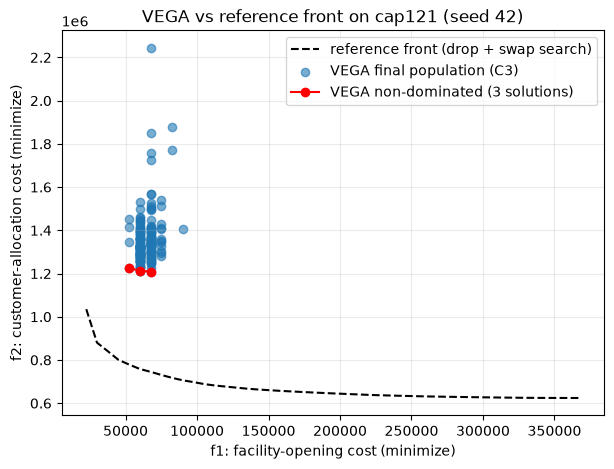

C1:
   VEGA f1 =    52,500  f2 =    1,469,533   reference f2 =      778,711   -> VEGA's allocation cost is 89% higher
   VEGA f1 =    67,500  f2 =    1,380,867   reference f2 =      745,178   -> VEGA's allocation cost is 85% higher
C2:
   VEGA f1 =    52,500  f2 =    1,555,781   reference f2 =      778,711   -> VEGA's allocation cost is 100% higher
   VEGA f1 =    60,000  f2 =    1,262,842   reference f2 =      758,266   -> VEGA's allocation cost is 67% higher


C3:
   VEGA f1 =    52,500  f2 =    1,225,511   reference f2 =      778,711   -> VEGA's allocation cost is 57% higher
   VEGA f1 =    60,000  f2 =    1,212,651   reference f2 =      758,266   -> VEGA's allocation cost is 60% higher
   VEGA f1 =    67,500  f2 =    1,209,356   reference f2 =      745,178   -> VEGA's allocation cost is 62% higher


In [18]:
# Step 17: VEGA against the reference front, drawn like the lab's plot.
#   dashed black line = the reference front (our yardstick, like the lab's "true Pareto front")
#   blue dots         = VEGA's final population (configuration C3)
#   red line          = VEGA's non-dominated trendline
# The closer VEGA's red line is to the dashed line, the better. In the lab the dots sat ON the curve;
# here we can see how far above it VEGA ends up, and how little of the trade-off it covers.

final_objectives, history = run_vega(instance, CONFIGS[2], SEED)  # C3
vega_front = nondominated(final_objectives)

plt.figure(figsize=(7, 5))
plt.plot([r[0] for r in reference], [r[1] for r in reference], "k--", label="reference front (drop + swap search)")
plt.scatter([o[0] for o in final_objectives], [o[1] for o in final_objectives], alpha=0.6,
            label="VEGA final population (C3)")
plt.plot([o[0] for o in vega_front], [o[1] for o in vega_front], "o-", color="red",
         label=f"VEGA non-dominated ({len(vega_front)} solutions)")
plt.title(f"VEGA vs reference front on {instance['name']} (seed {SEED})")
plt.xlabel("f1: facility-opening cost (minimize)")
plt.ylabel("f2: customer-allocation cost (minimize)")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


# How far above the reference is each VEGA solution?
# The reference is a staircase: without spending more than f1 on opening facilities, the best it reaches is the
# lowest f2 among its points with an opening cost of at most f1.

def reference_f2_at(f1, reference):
    candidates = [r_f2 for r_f1, r_f2 in reference if r_f1 <= f1]
    return min(candidates) if candidates else None


for config in CONFIGS:
    config_front = nondominated(run_vega(instance, config, SEED)[0])
    print(f"{config.name}:")
    for f1, f2 in config_front:
        best_f2 = reference_f2_at(f1, reference)
        if best_f2 is None:
            print(f"   VEGA f1 = {f1:>9,.0f}  f2 = {f2:>12,.0f}   (cheaper to open than any reference point)")
        else:
            print(f"   VEGA f1 = {f1:>9,.0f}  f2 = {f2:>12,.0f}   reference f2 = {best_f2:>12,.0f}"
                  f"   -> VEGA's allocation cost is {100 * (f2 / best_f2 - 1):.0f}% higher")